In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt
from tensorflow.python.keras.saving.saved_model import metric_serialization

### Load Data

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

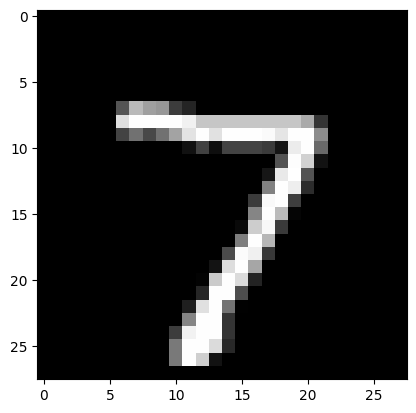

In [3]:
plt.imshow(X_test[0], cmap='gray')

### Processing The Data

In [4]:
X_train = X_train.reshape(60000,784).astype('float32')
X_valid = X_test.reshape(10000,784).astype('float32')

In [5]:
X_train /= 255
X_valid /= 255

In [6]:
n_classes = 10
y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_test,n_classes)

### Implementing the Neural Network

### Model 1

In [7]:
import warnings
warnings.filterwarnings('ignore')
model1 = Sequential()
# hidden layer
model1.add(Dense(64, activation='relu', input_shape=(784,)))
model1.add(BatchNormalization())

#second hidden layer
model1.add(Dense(64, activation='relu'))
model1.add(BatchNormalization())


#third hidden layer
model1.add(Dense(64, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.2))

#output layer
model1.add(Dense(10, activation='softmax'))
model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,978 (234.29 KB)

 Trainable params: 59,594 (232.79 KB)

 Non-trainable params: 384 (1.50 KB)

###

In [8]:
model1.compile(loss='categorical_crossentropy', optimizer ='nadam', metrics = ['accuracy'])

In [9]:
model1_hist = model1.fit(X_train, y_train, batch_size=128, epochs = 15, verbose =1, validation_data = (X_valid, y_valid))

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8779 - loss: 0.4061 - val_accuracy: 0.9475 - val_loss: 0.1717
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.9541 - loss: 0.1531 - val_accuracy: 0.9596 - val_loss: 0.1314
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - accuracy: 0.9651 - loss: 0.1151 - val_accuracy: 0.9662 - val_loss: 0.1179
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9723 - loss: 0.0916 - val_accuracy: 0.9678 - val_loss: 0.1038
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.9764 - loss: 0.0765 - val_accuracy: 0.9708 - val_loss: 0.0966
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.9793 - loss: 0.0649 - val_accuracy: 0.9704 - val_loss: 0.0996
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.9820 - loss: 0.0563 - val_accuracy: 0.9708 - val_loss: 0.0995
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9840 - loss: 0.0506 - val_ac

### Model2

In [10]:
model2 = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(64, activation='relu', input_shape=(784,)),
    BatchNormalization(),

    Dense(10, activation='softmax')
])
model2.compile(loss='categorical_crossentropy', optimizer='nadam', metrics=['accuracy'])

In [11]:
model2_hist= model2.fit(X_train, y_train, batch_size=128, epochs = 15,verbose =1, validation_data = (X_valid, y_valid))


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8706 - loss: 0.4283 - val_accuracy: 0.9497 - val_loss: 0.1628
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.9416 - loss: 0.1882 - val_accuracy: 0.9613 - val_loss: 0.1229
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.9540 - loss: 0.1487 - val_accuracy: 0.9656 - val_loss: 0.1054
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9589 - loss: 0.1311 - val_accuracy: 0.9668 - val_loss: 0.1044
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9641 - loss: 0.1142 - val_accuracy: 0.9683 - val_loss: 0.0944
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.9661 - loss: 0.1070 - val_accuracy: 0.9714 - val_loss: 0.0900
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.9684 - loss: 0.0978 - val_accuracy: 0.9719 - val_loss: 0.0846
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9727 - loss: 0.0877 - val_accu

### Plotting the results

In [12]:
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

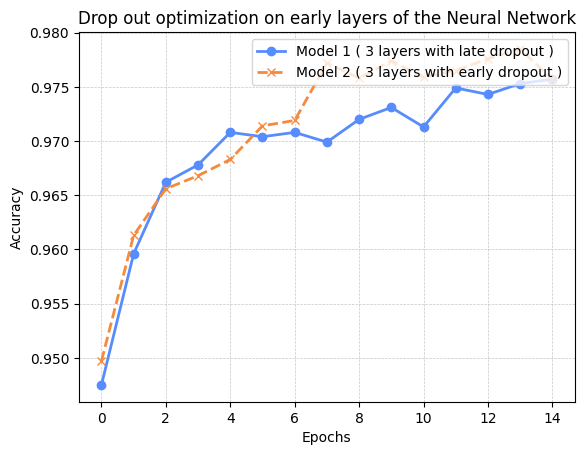

In [13]:
plt.plot(model1_hist.history['val_accuracy'], label= 'Model 1 ( 3 layers with late dropout )', marker='o', linewidth=2)
plt.plot(model2_hist.history['val_accuracy'], label= 'Model 2 ( 3 layers with early dropout )', marker='x', linewidth=2, linestyle='--')

plt.title('Drop out optimization on early layers of the Neural Network')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()